In [5]:
# Load libraries
import numpy as np
import matplotlib.pyplot as plt
from pandas import set_option
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_squared_error
from pathlib import Path


In [10]:
import pandas as pd

names = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE',
    'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV'
]

# Colab/local fallback search for dataset path.
candidate_paths = [
    Path('/content/housing.csv'),
    Path('/content/drive/MyDrive/housing.csv'),
    Path('housing.csv'),
]

data_path = next((path for path in candidate_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        "housing.csv not found. In Colab upload to /content or place it in /content/drive/MyDrive/."
    )

dataset = pd.read_csv(data_path, header=None, sep=r"\s+", names=names)
data = pd.DataFrame(dataset)
print(data.head())
print(data.shape)
print(data.describe())

data
# print(f"Loaded dataset from: {data_path}")
# print(dataset.head())
# print(dataset.shape)
# print(dataset.dtypes)

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  
(506, 14)
             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


In [3]:
# descriptions
set_option('display.precision', 1)
print(dataset.describe())

          CRIM     ZN  INDUS     CHAS    NOX     RM    AGE    DIS    RAD  \
count  5.1e+02  506.0  506.0  5.1e+02  506.0  506.0  506.0  506.0  506.0   
mean   3.6e+00   11.4   11.1  6.9e-02    0.6    6.3   68.6    3.8    9.5   
std    8.6e+00   23.3    6.9  2.5e-01    0.1    0.7   28.1    2.1    8.7   
min    6.3e-03    0.0    0.5  0.0e+00    0.4    3.6    2.9    1.1    1.0   
25%    8.2e-02    0.0    5.2  0.0e+00    0.4    5.9   45.0    2.1    4.0   
50%    2.6e-01    0.0    9.7  0.0e+00    0.5    6.2   77.5    3.2    5.0   
75%    3.7e+00   12.5   18.1  0.0e+00    0.6    6.6   94.1    5.2   24.0   
max    8.9e+01  100.0   27.7  1.0e+00    0.9    8.8  100.0   12.1   24.0   

         TAX  PTRATIO      B  LSTAT   MEDV  
count  506.0    506.0  506.0  506.0  506.0  
mean   408.2     18.5  356.7   12.7   22.5  
std    168.5      2.2   91.3    7.1    9.2  
min    187.0     12.6    0.3    1.7    5.0  
25%    279.0     17.4  375.4    6.9   17.0  
50%    330.0     19.1  391.4   11.4   21.2  


In [4]:
# correlation
set_option('display.precision', 2)
print(dataset.corr(method='pearson'))

         CRIM    ZN  INDUS      CHAS   NOX    RM   AGE   DIS       RAD   TAX  \
CRIM     1.00 -0.20   0.41 -5.59e-02  0.42 -0.22  0.35 -0.38  6.26e-01  0.58   
ZN      -0.20  1.00  -0.53 -4.27e-02 -0.52  0.31 -0.57  0.66 -3.12e-01 -0.31   
INDUS    0.41 -0.53   1.00  6.29e-02  0.76 -0.39  0.64 -0.71  5.95e-01  0.72   
CHAS    -0.06 -0.04   0.06  1.00e+00  0.09  0.09  0.09 -0.10 -7.37e-03 -0.04   
NOX      0.42 -0.52   0.76  9.12e-02  1.00 -0.30  0.73 -0.77  6.11e-01  0.67   
RM      -0.22  0.31  -0.39  9.13e-02 -0.30  1.00 -0.24  0.21 -2.10e-01 -0.29   
AGE      0.35 -0.57   0.64  8.65e-02  0.73 -0.24  1.00 -0.75  4.56e-01  0.51   
DIS     -0.38  0.66  -0.71 -9.92e-02 -0.77  0.21 -0.75  1.00 -4.95e-01 -0.53   
RAD      0.63 -0.31   0.60 -7.37e-03  0.61 -0.21  0.46 -0.49  1.00e+00  0.91   
TAX      0.58 -0.31   0.72 -3.56e-02  0.67 -0.29  0.51 -0.53  9.10e-01  1.00   
PTRATIO  0.29 -0.39   0.38 -1.22e-01  0.19 -0.36  0.26 -0.23  4.65e-01  0.46   
B       -0.39  0.18  -0.36  4.88e-02 -0.

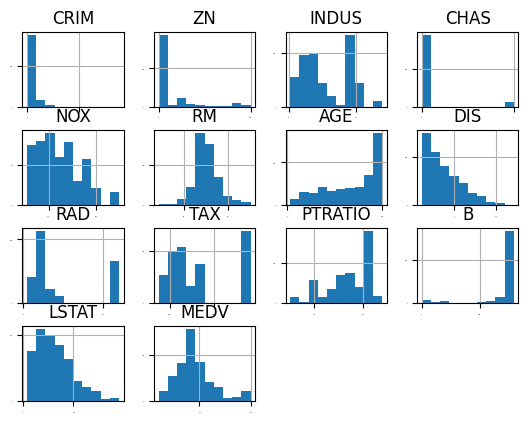

In [5]:
# histograms
dataset.hist(sharex=False, sharey=False, xlabelsize=1, ylabelsize=1)

plt.show()

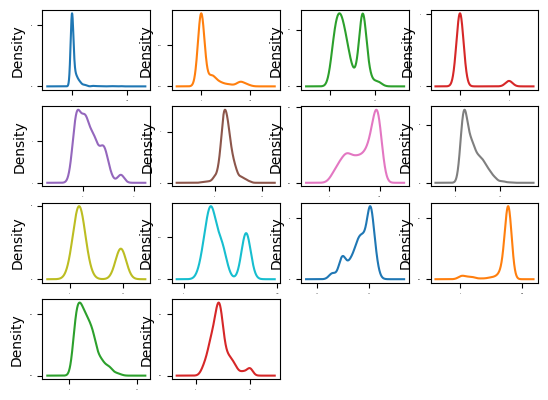

In [6]:
#density
# from matplotlib.pyplot import legend
# from torch import layout
# from matplotlib.pyplot import subplot
dataset.plot(kind='density', subplots=True, layout=(4,4), sharex=False, legend=False, fontsize=1)

plt.show()

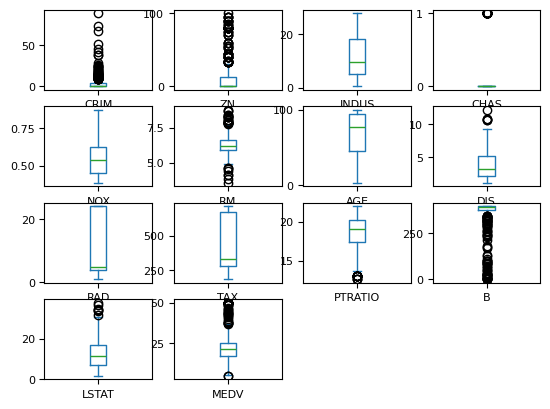

In [7]:
#box
dataset.plot(kind='box', subplots=True, layout=(4,4), sharex=False, sharey=False, fontsize=8)

plt.show()

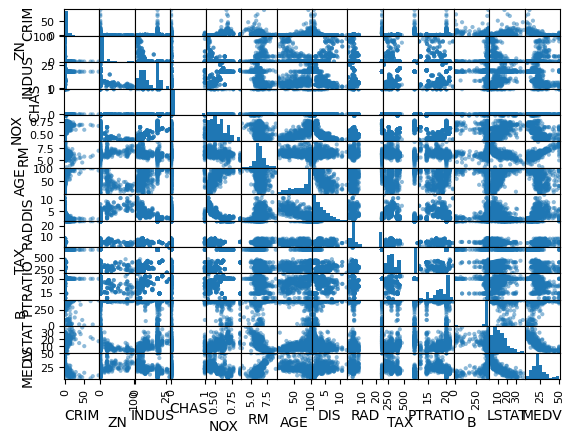

In [8]:
#scatter matirx
scatter_matrix(dataset)
plt.show()

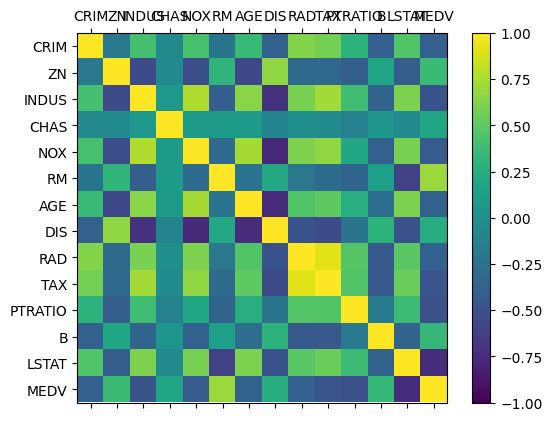

In [9]:
#correlation matrix
fig = plt.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(dataset.corr(), vmin=-1, vmax=1, interpolation='none')
fig.colorbar(cax)
ticks = np.arange(0,14,1)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(names)
ax.set_yticklabels(names)

plt.show()

In [10]:
# Split-out validation dataset
array = dataset.values
X = array[:,0:13]
Y = array[:,13]
validation_size = 0.20
seed = 7
X_train, X_validation, Y_train, Y_validation = train_test_split(X, Y, test_size=validation_size, random_state=seed)

In [11]:
# Test options and evaluation metric
num_folds = 10
seed = 7
scoring ='neg_mean_squared_error'

In [12]:
# Spot-Check Algorithms
models = []
models.append(('ScaledLR', Pipeline([('Scaler', StandardScaler()), ('LR', LinearRegression())])))
models.append(('ScaledLASSO', Pipeline([('Scaler', StandardScaler()), ('LASSO', Lasso(alpha=0.001, max_iter=20000, tol=1e-4))])))
models.append(('ScaledEN', Pipeline([('Scaler', StandardScaler()), ('EN', ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=20000, tol=1e-4, random_state=seed))])))
models.append(('ScaledKNN', Pipeline([('Scaler', StandardScaler()), ('KNN', KNeighborsRegressor())])))
models.append(('CART', DecisionTreeRegressor(random_state=seed)))
models.append(('ScaledSVR', Pipeline([('Scaler', StandardScaler()), ('SVR', SVR())])))


In [13]:
# evaluate each model in turn
results = []
names = []
for name, model in models:
    kfold = KFold(n_splits=num_folds, random_state=seed, shuffle=True)
    cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring=scoring, error_score='raise')
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)


ScaledLR: -22.006009 (12.188886)
ScaledLASSO: -22.006355 (12.190310)
ScaledEN: -22.002757 (12.189715)
ScaledKNN: -21.456867 (15.016218)
CART: -25.451587 (15.862360)
ScaledSVR: -29.570404 (18.052973)


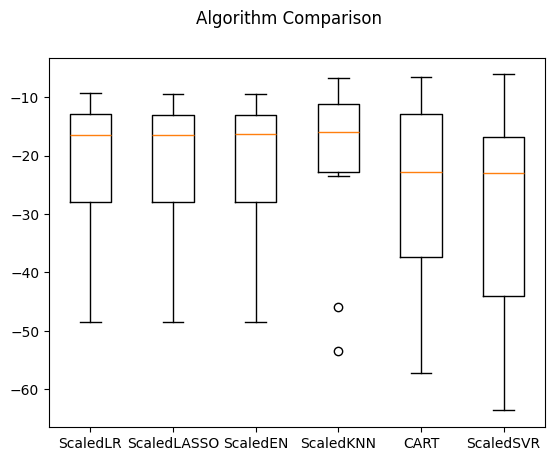

In [14]:
# Compare Algorithms
fig = plt.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

In [15]:
# Standardized comparison (kept as a separate section for readability)
pipelines = []
pipelines.append(('ScaledLR', Pipeline([('Scaler', StandardScaler()), ('LR', LinearRegression())])))
pipelines.append(('ScaledLASSO', Pipeline([('Scaler', StandardScaler()), ('LASSO', Lasso(alpha=0.001, max_iter=20000, tol=1e-4))])))
pipelines.append(('ScaledEN', Pipeline([('Scaler', StandardScaler()), ('EN', ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=20000, tol=1e-4, random_state=seed))])))
pipelines.append(('ScaledKNN', Pipeline([('Scaler', StandardScaler()), ('KNN', KNeighborsRegressor())])))
pipelines.append(('ScaledSVR', Pipeline([('Scaler', StandardScaler()), ('SVR', SVR())])))
pipelines.append(('CART', DecisionTreeRegressor(random_state=seed)))
results = []
names = []
for name, model in pipelines:
    kfold = KFold(n_splits=num_folds, shuffle=True, random_state=seed)
    cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring=scoring, error_score='raise')
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

ScaledLR: -22.006009 (12.188886)
ScaledLASSO: -22.006355 (12.190310)
ScaledEN: -22.002757 (12.189715)
ScaledKNN: -21.456867 (15.016218)
ScaledSVR: -29.570404 (18.052973)
CART: -25.451587 (15.862360)


In [16]:
# KNN Algorithm tuning
k_values = np.array([1,3,5,7,9,11,13,15,17,19,21])
param_grid = {'KNN__n_neighbors': k_values}
model = Pipeline([('Scaler', StandardScaler()), ('KNN', KNeighborsRegressor())])
kfold = KFold(n_splits=num_folds, shuffle=True, random_state=seed)
grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scoring, cv=kfold)
grid_result = grid.fit(X_train, Y_train)
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Best: -19.493073 using {'KNN__n_neighbors': np.int64(1)}
-19.493073 (15.772090) with: {'KNN__n_neighbors': np.int64(1)}
-19.773908 (13.239219) with: {'KNN__n_neighbors': np.int64(3)}
-21.456867 (15.016218) with: {'KNN__n_neighbors': np.int64(5)}
-21.220889 (14.192861) with: {'KNN__n_neighbors': np.int64(7)}
-21.194234 (14.760773) with: {'KNN__n_neighbors': np.int64(9)}
-21.494941 (14.750981) with: {'KNN__n_neighbors': np.int64(11)}
-21.509075 (14.759715) with: {'KNN__n_neighbors': np.int64(13)}
-22.082997 (14.253718) with: {'KNN__n_neighbors': np.int64(15)}
-22.769667 (14.594785) with: {'KNN__n_neighbors': np.int64(17)}
-23.674273 (14.893491) with: {'KNN__n_neighbors': np.int64(19)}
-24.330468 (15.013861) with: {'KNN__n_neighbors': np.int64(21)}


In [17]:
# ensembles
ensembles = []
ensembles.append(('AB', AdaBoostRegressor(random_state=seed)))
ensembles.append(('GBM', GradientBoostingRegressor(random_state=seed)))
ensembles.append(('RF', RandomForestRegressor(random_state=seed)))
ensembles.append(('ET', ExtraTreesRegressor(random_state=seed)))

results = []
names = []
for name, model in ensembles:
    kfold = KFold(n_splits=num_folds, shuffle=True, random_state=seed)
    cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

AB: -15.732481 (8.301119)
GBM: -11.083422 (8.769008)
RF: -12.704362 (10.071933)
ET: -9.154940 (6.297012)


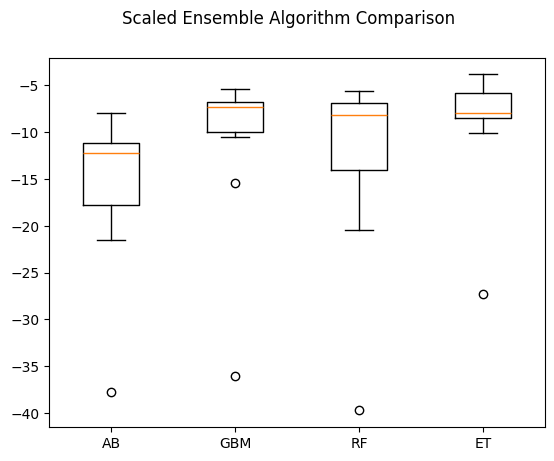

In [18]:
# Compare Algorithms
fig = plt.figure()
fig.suptitle('Scaled Ensemble Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

In [19]:
import sys
print(sys.executable)
print(sys.prefix)
print(sys.base_prefix)

/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv/bin/python
/Users/kamruzzamankhanalve/Documents/4-2 semester/CSE 4203 Machine Learning/CSE 4204/.venv
/Applications/Xcode.app/Contents/Developer/Library/Frameworks/Python3.framework/Versions/3.9


In [20]:
# Tune GBM
param_grid = dict(n_estimators=np.array([50,100,150,200,250,300,350,400]))
model = GradientBoostingRegressor(random_state=seed)
kfold = KFold(n_splits=num_folds, shuffle=True, random_state=seed)
grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scoring, cv=kfold)
grid_result = grid.fit(X_train, Y_train)

print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Best: -10.542686 using {'n_estimators': np.int64(400)}
-11.646884 (8.828096) with: {'n_estimators': np.int64(50)}
-11.083422 (8.769008) with: {'n_estimators': np.int64(100)}
-10.849002 (8.730697) with: {'n_estimators': np.int64(150)}
-10.792748 (8.654232) with: {'n_estimators': np.int64(200)}
-10.652079 (8.542726) with: {'n_estimators': np.int64(250)}
-10.639604 (8.496989) with: {'n_estimators': np.int64(300)}
-10.578039 (8.414088) with: {'n_estimators': np.int64(350)}
-10.542686 (8.352650) with: {'n_estimators': np.int64(400)}


In [21]:
# prepare the model
model = GradientBoostingRegressor(random_state=seed, n_estimators=400)
model.fit(X_train, Y_train)

GradientBoostingRegressor(n_estimators=400, random_state=7)

In [22]:
# transform the validation dataset
predictions = model.predict(X_validation)
print(mean_squared_error(Y_validation, predictions))

11.888259833558383


In [1]:
import pandas as pd

# Data
data = {
'Name': ['John', 'Anna', 'Peter', 'Linda', 'Dina', 'Kate', 'Tom', 'Emily'],
'Age': [22, 78, 22, 30, 45, 30, 35, 40],
'Gender': ['Male', 'Female', 'Male', 'Female', 'Female', 'Female', 'Male', 'Female'],
'City': ['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix', 'Philadelphia', 'San Antonio', 'San Diego'],
'Occupation': ['Engineer', 'Doctor', 'Teacher', 'Nurse', 'Architect', 'Lawyer', 'Accountant', 'Scientist']
}

# Create a DataFrame
df = pd.DataFrame(data)

# Display the DataFrame
df

,Name,Age,Gender,City,Occupation
0,John,22,Male,New York,Engineer
1,Anna,78,Female,Los Angeles,Doctor
2,Peter,22,Male,Chicago,Teacher
3,Linda,30,Female,Houston,Nurse
4,Dina,45,Female,Phoenix,Architect
5,Kate,30,Female,Philadelphia,Lawyer
6,Tom,35,Male,San Antonio,Accountant
7,Emily,40,Female,San Diego,Scientist
